<a href="https://colab.research.google.com/github/lekan-adeniyi051/DSN-ML-TRACK/blob/main/DSN_Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
# import datasets
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [4]:
train.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [5]:
train.shape

(6818, 13)

In [6]:
train.describe(include = 'all')

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
count,6818,6818,5593.000000,6818,6818.000000,6818,6818.000000,6818,6818.000000,4899,6818,6818,6818.000000
unique,6818,1555,NaN,2,NaN,48,NaN,10,NaN,3,3,4,NaN
top,row_08522,PRD-YZB4K8,NaN,Low Fat,NaN,Fruits and Vegetables,NaN,STORE-YLW,NaN,Medium,Tier_3,Standard Supermarket,NaN
freq,1,9,NaN,4425,NaN,480,NaN,754,NaN,2218,2677,4462,NaN
mean,NaN,NaN,12.850876,NaN,0.065527,NaN,140.473623,NaN,34.178205,NaN,NaN,NaN,2174.756574
std,NaN,NaN,4.646542,NaN,0.051566,NaN,62.413513,NaN,8.384574,NaN,NaN,NaN,1697.894956
min,NaN,NaN,4.482000,NaN,0.000000,NaN,31.110000,NaN,23.000000,NaN,NaN,NaN,32.700000
25%,NaN,NaN,8.750000,NaN,0.026600,NaN,93.280000,NaN,28.000000,NaN,NaN,NaN,834.792500
50%,NaN,NaN,12.647000,NaN,0.053200,NaN,142.065000,NaN,33.000000,NaN,NaN,NaN,1790.890000
75%,NaN,NaN,16.894000,NaN,0.093400,NaN,185.987500,NaN,45.000000,NaN,NaN,NaN,3092.587500


In [7]:
train.isnull().sum()

,0
id,0
product_code,0
product_weight_kg,1225
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,1919


In [8]:
test.isnull().sum()

,0
id,0
product_code,0
product_weight_kg,306
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,491


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


## Data cleaning

#Our approach
      1 -EDA
      2 -Check linear relationships with total_sales
      3 -Handle missing values
      4 -Encode categorical variables
      5 -Handle numerical features/scaling where appropriate
      6 -Check multicollinearity
      7 -Split data into train/validation
      8 -Train LinearRegression
      9 -Evaluate using the appropriate regression metrics
      10 -Analyze residuals
      11 - Improve the linear model through feature engineering
      12 -Train on the full training set
      13 -Generate Kaggle predictions item






##Actual Data Cleaning

In [10]:
for col in train.select_dtypes(include = 'object').columns:
    print(f"\n{col}")
    print(train[col].unique())


id
['row_00000' 'row_00001' 'row_00002' ... 'row_08520' 'row_08521'
 'row_08522']

product_code
['PRD-PRFP9S' 'PRD-PXXK71' 'PRD-V5MOIJ' ... 'PRD-AF3WE8' 'PRD-06GUU9'
 'PRD-7Q5FPH']

fat_content
['Low Fat' 'Regular']

product_category
['Frozen Foods' 'HEALTH AND HYGIENE' 'Canned' 'soft drinks' 'meat'
 'Snack Foods' 'baking goods' 'household' 'Household' 'Dairy' 'dairy'
 'CANNED' 'SNACK FOODS' 'HOUSEHOLD' 'Soft Drinks' 'Fruits and Vegetables'
 'Breakfast' 'Breads' 'Meat' 'BAKING GOODS' 'canned' 'DAIRY' 'breakfast'
 'Baking Goods' 'Health and Hygiene' 'MEAT' 'Seafood'
 'fruits and vegetables' 'frozen foods' 'snack foods' 'FROZEN FOODS'
 'Others' 'FRUITS AND VEGETABLES' 'health and hygiene' 'OTHERS' 'BREADS'
 'SEAFOOD' 'SOFT DRINKS' 'Hard Drinks' 'breads' 'starchy foods'
 'hard drinks' 'HARD DRINKS' 'others' 'Starchy Foods' 'seafood'
 'BREAKFAST' 'STARCHY FOODS']

store_code
['STORE-AGY' 'STORE-YLW' 'STORE-89Z' 'STORE-7WS' 'STORE-9RG' 'STORE-HL7'
 'STORE-JOR' 'STORE-T5G' 'STORE-OYG' 'STOR

In [11]:
## convert product category into homogenous case
train['product_category'] = train['product_category'].str.strip().str.upper()
test['product_category'] =  test['product_category'].str.strip().str.upper()


# Median weight for each product code
weight_map = train.groupby('product_code')['product_weight_kg'].median()

# Fill missing weights using the product's median weight
train['product_weight_kg'] = train['product_weight_kg'].fillna(train['product_code'].map(weight_map))
test['product_weight_kg'] = test['product_weight_kg'].fillna(test['product_code'].map(weight_map))

# Fallback for product codes with no known weight
overall_median = train['product_weight_kg'].median()

train['product_weight_kg'] = train['product_weight_kg'].fillna(overall_median)
test['product_weight_kg'] = test['product_weight_kg'].fillna(overall_median)


#  fill store size by mapping them to their respective store code
size_map = {
    'STORE-7WS': 'Medium',
    'STORE-89Z': 'Medium',
    'STORE-9RG': 'Small',
    'STORE-AGY': 'Large',
    'STORE-HL7': 'Medium',
    'STORE-JOR': 'Small',
    'STORE-T5G': 'Small',
    'STORE-YLW': 'Small'
}

train['store_size'] = train['store_size'].fillna(
    train['store_code'].map(size_map)
)

test['store_size'] = test['store_size'].fillna(
    test['store_code'].map(size_map)
)


# then fill the rest with "Misiing"
train['store_size'] = train['store_size'].fillna('Missing')
test['store_size'] = test['store_size'].fillna('Missing')


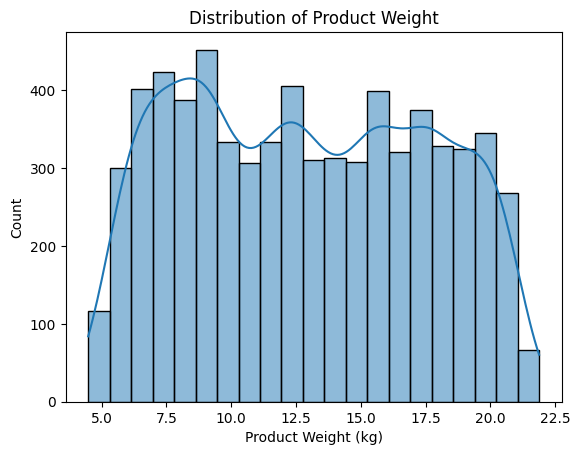

In [56]:
sns.histplot(train['product_weight_kg'], kde=True)

plt.xlabel('Product Weight (kg)')
plt.title('Distribution of Product Weight')
plt.show()

In [13]:

train.groupby('store_code')['product_weight_kg'].count()

,product_weight_kg
store_code,
STORE-7WS,748
STORE-89Z,728
STORE-9RG,752
STORE-AGY,748
STORE-DKU,736
STORE-HL7,742
STORE-JOR,439
STORE-OYG,744
STORE-T5G,427


In [14]:
train[(train['store_code'] == 'STORE-T5G') | (train['store_code'] == 'STORE-7WS')].count()

,0
id,1175
product_code,1175
product_weight_kg,1175
fat_content,1175
shelf_visibility,1175
product_category,1175
product_price,1175
store_code,1175
store_age_years,1175
store_size,1175


In [15]:
train.groupby('store_code')['product_weight_kg'].apply(
    lambda x: x.isna().mean()*100
)

,product_weight_kg
store_code,
STORE-7WS,0.0
STORE-89Z,0.0
STORE-9RG,0.0
STORE-AGY,0.0
STORE-DKU,0.0
STORE-HL7,0.0
STORE-JOR,0.0
STORE-OYG,0.0
STORE-T5G,0.0


In [16]:
train.groupby('product_code')['product_weight_kg'].nunique().describe()

,product_weight_kg
count,1555.000000
mean,3.905466
std,1.471546
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,9.000000


In [58]:
train.groupby('product_code')['product_weight_kg'].apply(
    lambda x: x.isna().sum()
).describe()

,product_weight_kg
count,1555.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [18]:
train.groupby('store_code')['store_size'].apply(
    lambda x: x.isna().mean() * 100
)

,store_size
store_code,
STORE-7WS,0.0
STORE-89Z,0.0
STORE-9RG,0.0
STORE-AGY,0.0
STORE-DKU,0.0
STORE-HL7,0.0
STORE-JOR,0.0
STORE-OYG,0.0
STORE-T5G,0.0


In [19]:
train.groupby('store_code')['store_size'].count()

,store_size
store_code,
STORE-7WS,748
STORE-89Z,728
STORE-9RG,752
STORE-AGY,748
STORE-DKU,736
STORE-HL7,742
STORE-JOR,439
STORE-OYG,744
STORE-T5G,427


In [20]:
pd.crosstab(
    train['store_format'],
    train['store_size'],
)

store_size,Large,Medium,Missing,Small
store_format,,,,
Corner Shop,0,0,0,866
Flagship Hypermarket,0,748,0,0
Standard Supermarket,748,728,1480,1506
Superstore,0,742,0,0


In [21]:
train.groupby(['store_format','store_code']).size().unstack()

store_code,STORE-7WS,STORE-89Z,STORE-9RG,STORE-AGY,STORE-DKU,STORE-HL7,STORE-JOR,STORE-OYG,STORE-T5G,STORE-YLW
store_format,,,,,,,,,,
Corner Shop,NaN,NaN,NaN,NaN,NaN,NaN,439.0,NaN,427.0,NaN
Flagship Hypermarket,748.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Standard Supermarket,NaN,728.0,752.0,748.0,736.0,NaN,NaN,744.0,NaN,754.0
Superstore,NaN,NaN,NaN,NaN,NaN,742.0,NaN,NaN,NaN,NaN


In [22]:
train.groupby('store_code')['store_size'].apply(
    lambda x: x.isna().mean() * 100
)

,store_size
store_code,
STORE-7WS,0.0
STORE-89Z,0.0
STORE-9RG,0.0
STORE-AGY,0.0
STORE-DKU,0.0
STORE-HL7,0.0
STORE-JOR,0.0
STORE-OYG,0.0
STORE-T5G,0.0


In [23]:
pd.crosstab(
    train['store_code'],
    train['store_size']
)

store_size,Large,Medium,Missing,Small
store_code,,,,
STORE-7WS,0,748,0,0
STORE-89Z,0,728,0,0
STORE-9RG,0,0,0,752
STORE-AGY,748,0,0,0
STORE-DKU,0,0,736,0
STORE-HL7,0,742,0,0
STORE-JOR,0,0,0,439
STORE-OYG,0,0,744,0
STORE-T5G,0,0,0,427


**EXPLORATORY DATA ANALYSIS**

<Axes: >

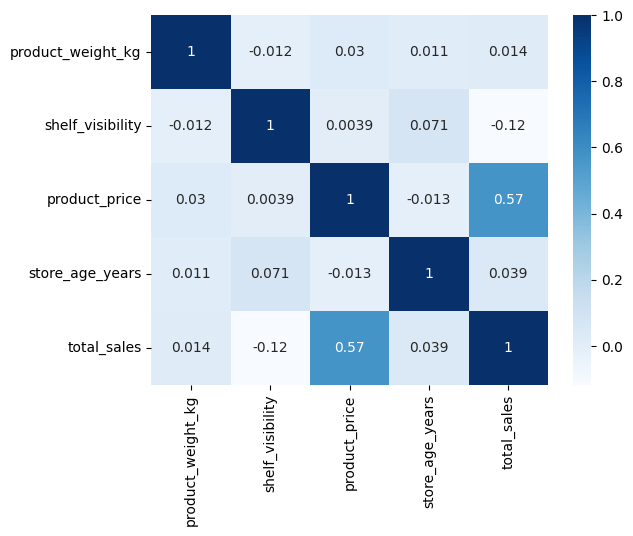

In [24]:
train_num  = train.select_dtypes(include = ['int64' , 'float64'])
sns.heatmap(train_num.corr(),annot = True,cmap = 'Blues')

# sales is highly correlated with price
# followed by a negative correlation with shelf visibility and price

In [25]:
print(train.groupby('store_format')['total_sales'].mean().sort_values())

print(train.groupby('store_format')['total_sales'].count())

print(train.groupby('store_format')['product_price'].mean().sort_values())

store_format
Corner Shop              336.353868
Superstore              1971.661954
Standard Supermarket    2316.319677
Flagship Hypermarket    3660.182219
Name: total_sales, dtype: float64
store_format
Corner Shop              866
Flagship Hypermarket     748
Standard Supermarket    4462
Superstore               742
Name: total_sales, dtype: int64
store_format
Corner Shop             138.070531
Flagship Hypermarket    139.438409
Superstore              140.185283
Standard Supermarket    141.161513
Name: product_price, dtype: float64


In [26]:
pd.crosstab(train['store_format'],train['store_location_tier'])

store_location_tier,Tier_1,Tier_2,Tier_3
store_format,,,
Corner Shop,427,0,439
Flagship Hypermarket,0,0,748
Standard Supermarket,1482,2232,748
Superstore,0,0,742


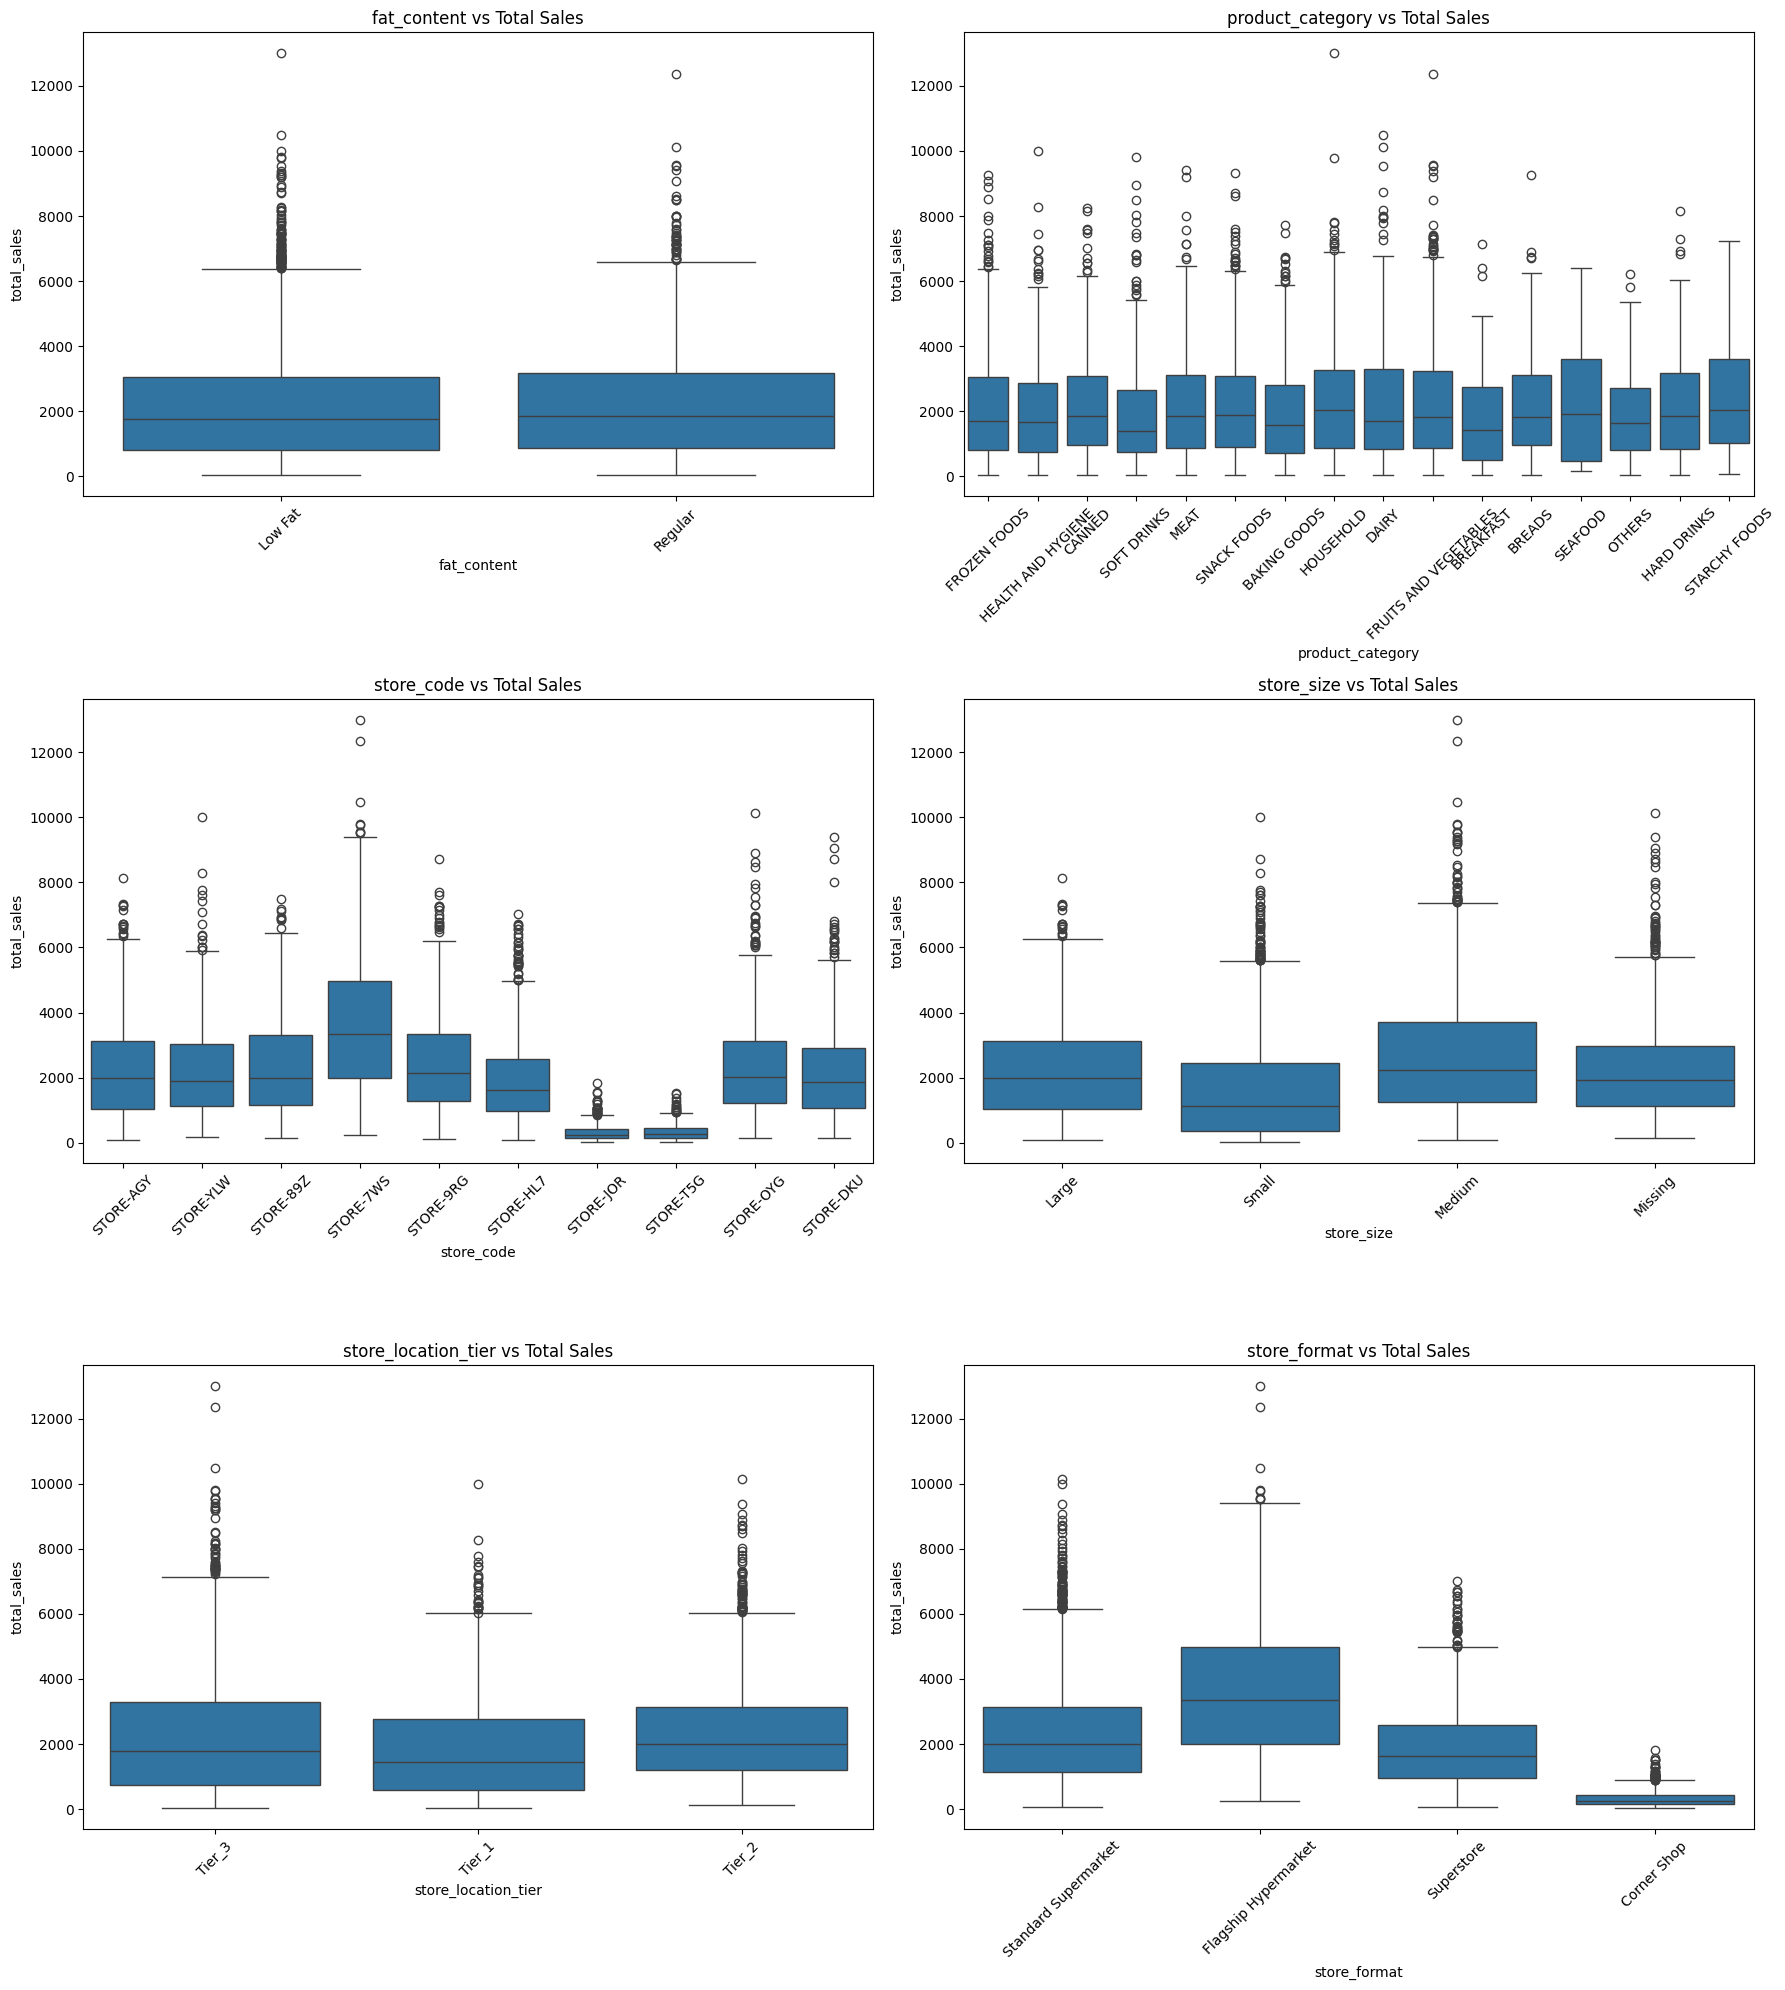

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = [
    'fat_content',
    'product_category',
    'store_code',
    'store_size',
    'store_location_tier',
    'store_format'
]

fig, axes = plt.subplots(3, 2, figsize=(18, 20))

for ax, col in zip(axes.flatten(), categorical_cols):
    sns.boxplot(data=train, x=col, y='total_sales', ax=ax)
    ax.set_title(f'{col} vs Total Sales')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

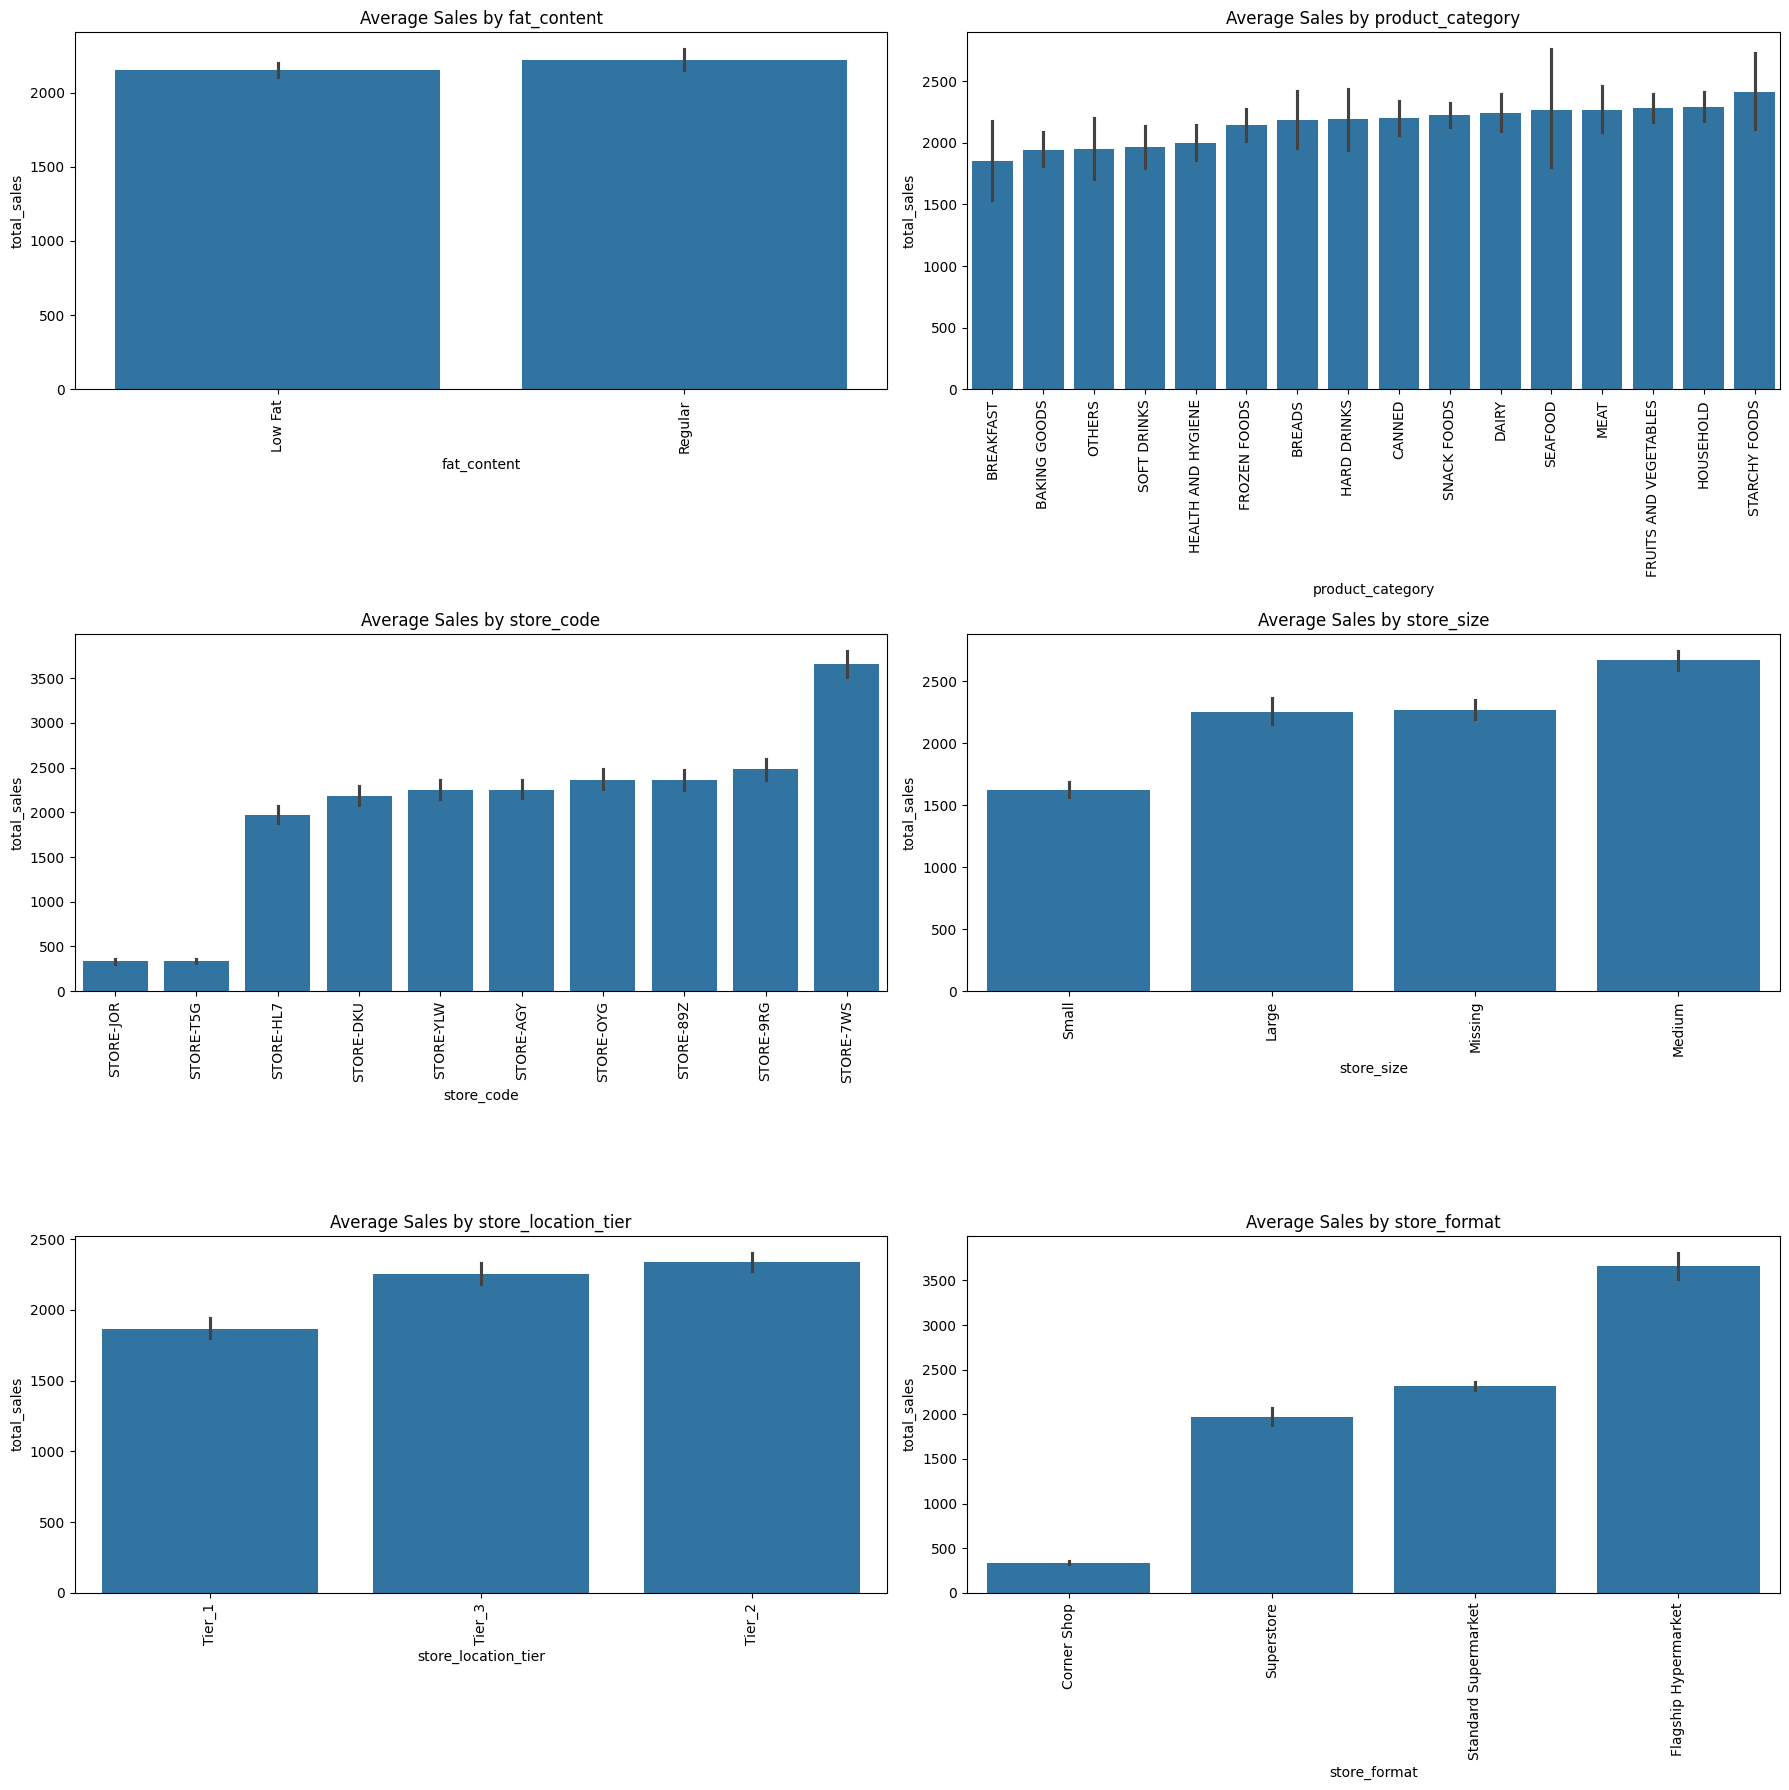

In [28]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

for ax, col in zip(axes.flatten(), categorical_cols):
    order = train.groupby(col)['total_sales'].mean().sort_values().index

    sns.barplot(
        data=train,
        x=col,
        y='total_sales',
        order=order,
        ax=ax
    )

    ax.set_title(f'Average Sales by {col}')
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

# **Training Models**

In [66]:
 # define x and y
x = train.drop('total_sales',axis = 1).drop('id',axis = 1).drop('product_code',axis = 1)
y = train['total_sales']


 # also define  x_test set for predicting even though we are not traeinig with it
x_test = test.drop('id',axis = 1).drop('product_code',axis = 1)
y


,total_sales
0,1764.98
1,342.13
2,378.85
3,5595.72
4,2375.36
...,...
6813,276.50
6814,1265.63
6815,6254.55
6816,1658.06


In [30]:
# train_test_split
from sklearn.model_selection import train_test_split
x_train,x_val,y_train,y_val = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [31]:
categorical_cols = ['fat_content', 'product_category', 'store_code', 'store_size',
       'store_location_tier', 'store_format']
numerical_cols = ['product_weight_kg', 'shelf_visibility', 'product_price',
       'store_age_years']

In [67]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

x_train_encoded = preprocessor.fit_transform(x_train)
x_val_encoded = preprocessor.transform(x_val)

# for the real test set
x_test = preprocessor.transform(x_test)



In [54]:
from sklearn.linear_model import LinearRegression
ln = LinearRegression()
ln.fit(x_train_encoded,y_train)
y_pred = ln.predict(x_val_encoded)

In [34]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error( y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("MAE : ", mae)
print("RMSE : ", rmse)

print("R2_Score : ", r2)

MAE :  843.8430724884976
RMSE :  1122.5872733699377
R2_Score :  0.571982271227958


In [35]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rmse_scores = -cross_val_score(
    pipeline,
    x_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

print("RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

RMSE scores: [1109.38897566 1139.78007319 1135.69751831 1194.84001644 1086.58659987]
Mean RMSE: 1133.2586366929233
Std RMSE: 36.30091830222701


## Now to train on real test set

In [71]:
test_pred = ln.predict(x_test)
test_pred.shape

(1705,)

In [76]:
submission = pd.DataFrame({'Names':test['id'] , 'total_sales' : test_pred})
submission.to_csv(r'C:\Users\hp\Desktop\DSN Hackathon\submission.csv',index = False)